# 01 - Data Understanding

Load the customer support tickets dataset, inspect its schema, and review data quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy

print("Everything is working!")

Everything is working!


In [2]:
df = pd.read_csv('D:\\customer_support-ai\\data\\customer_support_tickets.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Priority,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,TKT-1001,Arjun Sharma,invalid_email,Wireless Mouse,03-12-2025,Product Question,Refund request,Need information about warranty,Low,8.3,214.3,1
1,TKT-1002,Isha Krishnan,isha.krishnan5@gmail.com,laptop pro 15,01-08-2025,Product Question,Compatibility issue,Bluetooth connection drops frequently.,Low,7.0,172.4,5
2,TKT-1003,Devansh Joshi,invalid_email,gaming console z,03-09-2025,Product Question,Warranty inquiry,unacceptable delay! Need information about wa...,High,5.1,192.4,3
3,TKT-1004,Devansh Sharma,devansh.sharma3@gmail.com,wireless mouse,03-07-2025,Cancellation Request,Product setup,Delivery arrived much later than expected.,Low,18.8,103.8,5
4,TKT-1005,Ananya Patel,invalid_email,smartwatch v2,02-01-2025,Cancellation Request,Delivery delay,Not compatible with my device.,Low,18.8,131.0,4


In [3]:
df.shape

(341, 12)

In [4]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Product Purchased',
       'Date of Purchase', 'Ticket Type', 'Ticket Subject',
       'Ticket Description', 'Ticket Priority', 'First Response Time',
       'Time to Resolution', 'Customer Satisfaction Rating'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     341 non-null    object 
 1   Customer Name                 341 non-null    object 
 2   Customer Email                341 non-null    object 
 3   Product Purchased             341 non-null    object 
 4   Date of Purchase              341 non-null    object 
 5   Ticket Type                   341 non-null    object 
 6   Ticket Subject                341 non-null    object 
 7   Ticket Description            341 non-null    object 
 8   Ticket Priority               341 non-null    object 
 9   First Response Time           341 non-null    float64
 10  Time to Resolution            341 non-null    float64
 11  Customer Satisfaction Rating  341 non-null    int64  
dtypes: float64(2), int64(1), object(9)
memory usage: 32.1+ KB


In [6]:
df.describe()

,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,341.000000,341.000000,341.000000
mean,10.872141,165.434897,3.055718
std,7.489916,41.265295,1.430694
min,0.200000,72.400000,1.000000
25%,2.400000,134.000000,2.000000
50%,11.300000,166.400000,3.000000
75%,17.200000,196.200000,4.000000
max,23.400000,235.100000,5.000000


In [7]:
df.nunique()

Ticket ID                       341
Customer Name                   125
Customer Email                  200
Product Purchased                15
Date of Purchase                 44
Ticket Type                       8
Ticket Subject                   13
Ticket Description               74
Ticket Priority                   3
First Response Time              52
Time to Resolution               60
Customer Satisfaction Rating      5
dtype: int64

In [8]:
df['Ticket Priority'].value_counts()

Ticket Priority
High      172
Medium    154
Low        15
Name: count, dtype: int64

In [9]:
df['Time to Resolution'].describe()

count    341.000000
mean     165.434897
std       41.265295
min       72.400000
25%      134.000000
50%      166.400000
75%      196.200000
max      235.100000
Name: Time to Resolution, dtype: float64

In [10]:
df_clean = df.copy()

In [11]:
df_clean.isnull().sum()

Ticket ID                       0
Customer Name                   0
Customer Email                  0
Product Purchased               0
Date of Purchase                0
Ticket Type                     0
Ticket Subject                  0
Ticket Description              0
Ticket Priority                 0
First Response Time             0
Time to Resolution              0
Customer Satisfaction Rating    0
dtype: int64

In [12]:
df.isnull().sum()/len(df) * 100

Ticket ID                       0.0
Customer Name                   0.0
Customer Email                  0.0
Product Purchased               0.0
Date of Purchase                0.0
Ticket Type                     0.0
Ticket Subject                  0.0
Ticket Description              0.0
Ticket Priority                 0.0
First Response Time             0.0
Time to Resolution              0.0
Customer Satisfaction Rating    0.0
dtype: float64

In [13]:
df_clean.duplicated().sum()

np.int64(0)

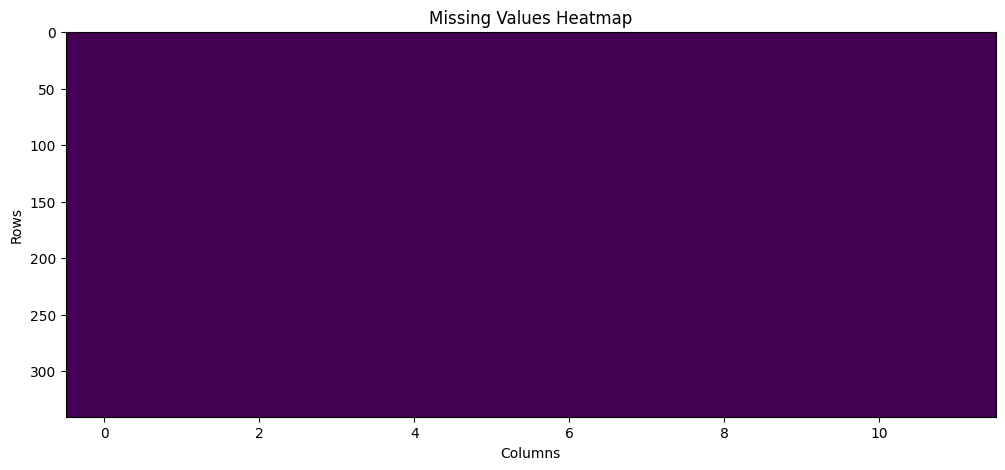

In [14]:
plt.figure(figsize=(12, 5))
plt.imshow(df_clean.isnull(),aspect='auto')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.title('Missing Values Heatmap')
plt.show()

In [15]:
df['Ticket ID'].duplicated().sum()

np.int64(0)

In [16]:
df_original = df.copy()

In [17]:
df.columns.tolist #check for trail spaces in the columns

<bound method IndexOpsMixin.tolist of Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Product Purchased',
       'Date of Purchase', 'Ticket Type', 'Ticket Subject',
       'Ticket Description', 'Ticket Priority', 'First Response Time',
       'Time to Resolution', 'Customer Satisfaction Rating'],
      dtype='object')>

In [18]:
df.dtypes #date of purchase is object type, need to convert to datetime

Ticket ID                        object
Customer Name                    object
Customer Email                   object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Priority                  object
First Response Time             float64
Time to Resolution              float64
Customer Satisfaction Rating      int64
dtype: object

In [19]:
df[df.duplicated]

,Ticket ID,Customer Name,Customer Email,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Priority,First Response Time,Time to Resolution,Customer Satisfaction Rating


In [20]:
sorted(df['Product Purchased'].unique()) #needs modification as they point to same product but have different case

['4k monitor 27in',
 'Wireless Mouse',
 'bluetooth speaker',
 'fitness band',
 'gaming console z',
 'gaming mouse',
 'laptop pro 15',
 'noise-canceling headphones',
 'power bank',
 'smart plug',
 'smartwatch',
 'smartwatch v2',
 'wireless earbud',
 'wireless keyboard',
 'wireless mouse']

In [21]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_columns].describe()

,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,341.000000,341.000000,341.000000
mean,10.872141,165.434897,3.055718
std,7.489916,41.265295,1.430694
min,0.200000,72.400000,1.000000
25%,2.400000,134.000000,2.000000
50%,11.300000,166.400000,3.000000
75%,17.200000,196.200000,4.000000
max,23.400000,235.100000,5.000000


In [22]:
df[df['First Response Time']<0]

,Ticket ID,Customer Name,Customer Email,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Priority,First Response Time,Time to Resolution,Customer Satisfaction Rating


In [23]:
email_pattern = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"
df[~df['Customer Email'].str.match(email_pattern)]

,Ticket ID,Customer Name,Customer Email,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Priority,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,TKT-1001,Arjun Sharma,invalid_email,Wireless Mouse,03-12-2025,Product Question,Refund request,Need information about warranty,Low,8.3,214.3,1
2,TKT-1003,Devansh Joshi,invalid_email,gaming console z,03-09-2025,Product Question,Warranty inquiry,unacceptable delay! Need information about wa...,High,5.1,192.4,3
4,TKT-1005,Ananya Patel,invalid_email,smartwatch v2,02-01-2025,Cancellation Request,Delivery delay,Not compatible with my device.,Low,18.8,131.0,4
5,TKT-1006,Diya Nair,invalid_email,smartwatch v2,2/19/2025,Technical Issue,Delivery delay,Application crashes frequently. (disappointed ...,Medium,19.3,143.0,3
9,TKT-1010,Siddharth Rao,invalid_email,wireless mouse,1/24/2025,Cancellation Request,Billing error,terrible experience! Double charge on credit c...,High,22.1,89.5,4
...,...,...,...,...,...,...,...,...,...,...,...,...
308,TKT-1309,Devansh Rao,invalid_email,smartwatch v2,2/13/2025,Billing Inquiry,Software bug,unacceptable delay! Application crashes freque...,High,17.2,166.4,4
311,TKT-1312,Siddharth Verma,invalid_email,bluetooth speaker,3/27/2025,Billing Inquiry,Product setup,disappointed! Delivery arrived much later than...,High,8.1,192.4,3
313,TKT-1314,Siddharth Patel,invalid_email,gaming console z,03-02-2025,Billing Inquiry,Damaged item,unacceptable delay! Item damaged during transi...,High,1.0,173.8,4
314,TKT-1315,Aarav Verma,invalid_email,wireless mouse,01-11-2025,Cancellation Request,Software bug,Application crashes frequently. (need assistan...,Medium,0.8,96.5,2


In [24]:
(df['Ticket Description'].str.strip()=="").sum()

np.int64(0)

In [25]:
categorical_columns = ['Product Purchased', 'Ticket Priority', 'Ticket Type']
print("Categorical Columns:", categorical_columns)
for col in categorical_columns:
    print(f"----{col}----")
    print(sorted((df[col].apply(lambda x: repr(x)).unique())))

Categorical Columns: ['Product Purchased', 'Ticket Priority', 'Ticket Type']
----Product Purchased----
["'4k monitor 27in'", "'Wireless Mouse'", "'bluetooth speaker'", "'fitness band'", "'gaming console z'", "'gaming mouse'", "'laptop pro 15'", "'noise-canceling headphones'", "'power bank'", "'smart plug'", "'smartwatch v2'", "'smartwatch'", "'wireless earbud'", "'wireless keyboard'", "'wireless mouse'"]
----Ticket Priority----
["'High'", "'Low'", "'Medium'"]
----Ticket Type----
["'Billing Inquiry'", "'Cancellation Request'", "'Clarification Request'", "'General Feedback'", "'Inquiry'", "'Product Question'", "'Refund Request'", "'Technical Issue'"]


In [26]:
priority_percentage = df['Ticket Priority'].value_counts(normalize=True) * 100
print(priority_percentage)

Ticket Priority
High      50.439883
Medium    45.161290
Low        4.398827
Name: proportion, dtype: float64


<Axes: >

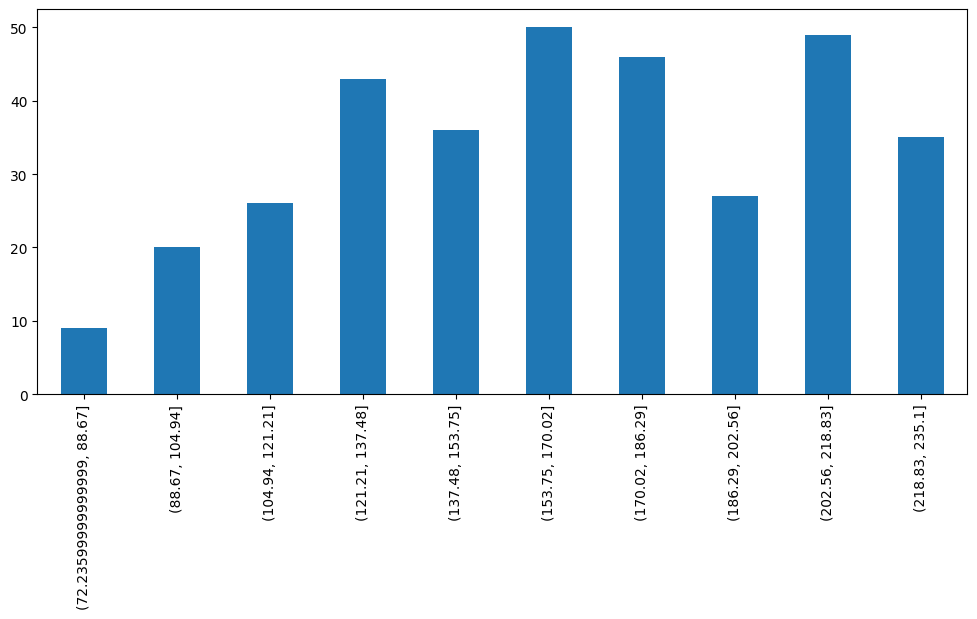

In [27]:
df['Time to Resolution'].value_counts(bins=10).sort_index().plot(kind='bar', figsize=(12, 5))